# Ablation 06: Graph Construction Parameters

Grid-searches patch_size ∈ {4, 7, 14} × k_neighbors ∈ {2, 3, 5, 8} to show how image-to-graph conversion quality affects GQMoE classification performance.

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
DRIVE_DIR    = '/content/drive/MyDrive/GQMoE'
ABLATION_DIR = f'{DRIVE_DIR}/ablations/06_graph_construction'
DATA_DIR     = f'{DRIVE_DIR}/data'
os.makedirs(ABLATION_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
requirements_path = f"{DRIVE_DIR}/requirements.txt"
!pip install -r "{requirements_path}"

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 33.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 60.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 35.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 145.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 

In [ ]:
import os, json, math, torch, itertools
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import knn_graph, global_mean_pool, GlobalAttention, GCNConv, GATConv, SAGEConv, GINConv
from torchvision import transforms
from sklearn.metrics import roc_auc_score
import pennylane as qml
torch.manual_seed(42); np.random.seed(42)


In [ ]:
base_config = {
    "file_path": f"{DATA_DIR}/retinamnist.npz",
    "batch_size": 32, "n_qubits": 8, "n_layers": 2,
    "expert_hidden": 64, "expert_out": 128, "top_k": 2,
    "n_iterations": 3, "n_classes": 5, "clf_hidden": 256, "dropout": 0.3,
    "epochs": 30,  # reduced for grid search speed
    "warmup_epochs": 3, "lr": 1e-3, "weight_decay": 1e-4,
    "aug_hflip": True, "aug_vflip": True, "aug_rotation": 15,
}

# Grid search: image is 28x28, so patch_size must divide 28
PATCH_SIZES  = [4, 7, 14]   # 49, 16, 4 patches respectively
K_NEIGHBORS  = [2, 3, 5, 8]
GRID = list(itertools.product(PATCH_SIZES, K_NEIGHBORS))
print(f"Total configurations: {len(GRID)}")
for ps, k in GRID:
    n_patches = (28 // ps) ** 2
    node_dim  = 3 * ps * ps
    print(f"  patch={ps}×{ps}  k={k}  →  {n_patches} nodes  node_dim={node_dim}")


Total configurations: 12
  patch=4×4  k=2  →  49 nodes  node_dim=48
  patch=4×4  k=3  →  49 nodes  node_dim=48
  patch=4×4  k=5  →  49 nodes  node_dim=48
  patch=4×4  k=8  →  49 nodes  node_dim=48
  patch=7×7  k=2  →  16 nodes  node_dim=147
  patch=7×7  k=3  →  16 nodes  node_dim=147
  patch=7×7  k=5  →  16 nodes  node_dim=147
  patch=7×7  k=8  →  16 nodes  node_dim=147
  patch=14×14  k=2  →  4 nodes  node_dim=588
  patch=14×14  k=3  →  4 nodes  node_dim=588
  patch=14×14  k=5  →  4 nodes  node_dim=588
  patch=14×14  k=8  →  4 nodes  node_dim=588


## Data & Model

In [ ]:
class MedMNISTGraphPipeline:
    def __init__(self,ps,k): self.ps=ps; self.k=k
    def process(self, img):
        c,h,w=img.shape; p=self.ps
        patches=img.unfold(1,p,p).unfold(2,p,p); n=patches.shape[1]*patches.shape[2]
        x=patches.contiguous().view(c,n,p*p).permute(1,0,2).reshape(n,-1)
        return Data(x=x, edge_index=knn_graph(x,k=self.k,loop=False))

class NPZDataset(Dataset):
    def __init__(self,path,split,pl,tf=None):
        self.pl=pl; self.tf=tf; d=np.load(path)
        self.imgs=d[f'{split}_images']; self.labs=d[f'{split}_labels']
    def __len__(self): return len(self.imgs)
    def __getitem__(self,i):
        img=torch.from_numpy(self.imgs[i]).float().permute(2,0,1)/255.
        if self.tf: img=self.tf(img)
        g=self.pl.process(img); lv=self.labs[i]; lv=lv.item() if lv.size==1 else lv[0]
        g.y=torch.tensor([lv],dtype=torch.long); return g

def build_tf(c):
    a=[]
    if c.get("aug_hflip"): a.append(transforms.RandomHorizontalFlip())
    if c.get("aug_vflip"): a.append(transforms.RandomVerticalFlip())
    if c.get("aug_rotation",0)>0: a.append(transforms.RandomRotation(c["aug_rotation"]))
    return transforms.Compose(a) if a else None

def build_model(fd, cfg):
    nq,nl,h,o = cfg["n_qubits"],cfg["n_layers"],cfg["expert_hidden"],cfg["expert_out"]

    class GCN(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1,self.c2=GCNConv(i,hi),GCNConv(hi,oo)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    class GAT(nn.Module):
        def __init__(self,i,hi,oo,hd): super().__init__(); self.c1=GATConv(i,hi,heads=hd,concat=True); self.c2=GATConv(hi*hd,oo,heads=1,concat=False)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    class SAGE(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1,self.c2=SAGEConv(i,hi),SAGEConv(hi,oo)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    class GIN(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1=GINConv(nn.Sequential(nn.Linear(i,hi),nn.ReLU(),nn.Linear(hi,hi))); self.c2=GINConv(nn.Sequential(nn.Linear(hi,oo),nn.ReLU(),nn.Linear(oo,oo)))
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)

    experts = [GCN(fd,h,o),GCN(fd,h*2,o),GAT(fd,h,o,4),GAT(fd,h,o,8),
               SAGE(fd,h,o),SAGE(fd,h*2,o),GIN(fd,h,o),GIN(fd,h*2,o)]

    class QR(nn.Module):
        def __init__(self):
            super().__init__(); self.enc=nn.Sequential(nn.Linear(fd,nq),nn.Tanh())
            dev=qml.device("default.qubit",wires=nq)
            @qml.qnode(dev,interface="torch",diff_method="backprop")
            def c(inputs,weights):
                qml.AngleEmbedding(inputs*math.pi,wires=range(nq),rotation="Y")
                for l in range(nl):
                    for q in range(nq): qml.RY(weights[l,q],wires=q)
                    for q in range(nq): qml.CNOT(wires=[q,(q+1)%nq])
                return [qml.expval(qml.PauliZ(q)) for q in range(nq)]
            self.vqc=qml.qnn.TorchLayer(c,{"weights":(nl,nq)})
        def forward(self,g): return torch.softmax(self.vqc(self.enc(g)),-1)

    class Model(nn.Module):
        def __init__(self):
            super().__init__(); self.router=QR(); self.experts=nn.ModuleList(experts)
            self.proj=nn.Linear(o,fd); self.norm=nn.LayerNorm(fd); self.top_k=cfg["top_k"]; self.n_iter=cfg["n_iterations"]
            self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(fd,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))
            self.clf=nn.Sequential(nn.Linear(fd,cfg["clf_hidden"]),nn.ReLU(),nn.Dropout(cfg["dropout"]),nn.Linear(cfg["clf_hidden"],cfg["n_classes"]))
        def forward(self,bd):
            b=bd.clone()
            for i in range(self.n_iter):
                g=global_mean_pool(b.x,b.batch); rw=self.router(g)
                tv,ti=torch.topk(rw,self.top_k,-1); sp=torch.zeros_like(rw).scatter_(1,ti,tv); sp/=sp.sum(-1,keepdim=True)
                outs=torch.stack([e(b.x,b.edge_index,b.batch) for e in self.experts],1)
                mo=(sp.unsqueeze(-1)*outs).sum(1)
                if i<self.n_iter-1: b.x=self.norm(b.x+self.proj(mo[b.batch]))
            return self.clf(self.pool(b.x,b.batch))

    return Model()


## Grid Search

In [ ]:
@torch.no_grad()
def evaluate(model, loader, crit, device):
    model.eval(); ls,c,tot=0.,0,0; p,l=[],[]
    for b in loader:
        b=b.to(device); lg=model(b); lb=b.y.squeeze()
        ls+=crit(lg,lb).item()*b.num_graphs; c+=(lg.argmax(-1)==lb).sum().item(); tot+=b.num_graphs
        p.append(torch.softmax(lg,-1).cpu()); l.append(lb.cpu())
    pr=torch.cat(p).numpy(); lb=torch.cat(l).numpy()
    auc=roc_auc_score(lb,pr,multi_class="ovr",average="macro") if len(np.unique(lb))>1 else float("nan")
    return ls/tot, c/tot, auc

# ── Checkpoint helpers ────────────────────────────────────────────────────────
CKPT_FILE = f"{ABLATION_DIR}/grid_results.json"

def save_results(results):
    with open(CKPT_FILE, "w") as f:
        json.dump({f"ps{key[0]}_k{key[1]}": v for key, v in results.items()}, f)

def load_results():
    if not os.path.exists(CKPT_FILE):
        return {}
    with open(CKPT_FILE) as f:
        raw = json.load(f)
    return {(int(s.split("_k")[0][2:]), int(s.split("_k")[1])): v for s, v in raw.items()}
# ─────────────────────────────────────────────────────────────────────────────

grid_results = load_results()
if grid_results:
    done = [f"ps{ps}_k{k}" for ps, k in grid_results]
    print(f"Resuming: {len(grid_results)}/{len(GRID)} configs already done: {done}")

tf = build_tf(base_config)

for patch_size, k in GRID:
    name = f"ps{patch_size}_k{k}"

    if (patch_size, k) in grid_results:
        print(f"Skipping {name} (already complete)")
        continue

    print(f"\n=== patch_size={patch_size}  k_neighbors={k} ===")
    pl = MedMNISTGraphPipeline(patch_size, k)
    tr = DataLoader(NPZDataset(base_config["file_path"],'train',pl,tf), base_config["batch_size"], shuffle=True)
    vl = DataLoader(NPZDataset(base_config["file_path"],'val',  pl),    base_config["batch_size"])
    te = DataLoader(NPZDataset(base_config["file_path"],'test', pl),    base_config["batch_size"])

    fd     = next(iter(tr)).x.shape[1]
    model  = build_model(fd, base_config)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu"); model = model.to(device)
    crit   = nn.CrossEntropyLoss()
    opt    = torch.optim.Adam(model.parameters(), lr=base_config["lr"], weight_decay=base_config["weight_decay"])
    warmup = torch.optim.lr_scheduler.LinearLR(opt, 1e-3, 1., base_config["warmup_epochs"])
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(opt, base_config["epochs"] - base_config["warmup_epochs"])
    sched  = torch.optim.lr_scheduler.SequentialLR(opt, [warmup, cosine], [base_config["warmup_epochs"]])
    best   = 0.
    start_ep = 1

    # Resume from mid-config epoch checkpoint if available
    epoch_ckpt = f"{ABLATION_DIR}/epoch_ckpt_{name}.pt"
    if os.path.exists(epoch_ckpt):
        ec = torch.load(epoch_ckpt, map_location=device)
        model.load_state_dict(ec["model"])
        opt.load_state_dict(ec["opt"])
        sched.load_state_dict(ec["sched"])
        best     = ec["best"]
        start_ep = ec["epoch"] + 1
        print(f"  Resumed from epoch {ec['epoch']}  best_val={best:.4f}")

    for ep in range(start_ep, base_config["epochs"] + 1):
        model.train()
        for b in tr:
            b = b.to(device); opt.zero_grad()
            nn.CrossEntropyLoss()(model(b), b.y.squeeze()).backward(); opt.step()
        sched.step()
        _, va, _ = evaluate(model, vl, crit, device)
        if va > best:
            best = va
            torch.save(model.state_dict(), f"{ABLATION_DIR}/best_{name}.pt")
        if ep in (10, 20, 30):
            print(f"  ep {ep}: val_acc={va:.4f}")

        # Save epoch checkpoint so training can resume after interruption
        torch.save({"epoch": ep, "model": model.state_dict(),
                    "opt": opt.state_dict(), "sched": sched.state_dict(),
                    "best": best}, epoch_ckpt)

    model.load_state_dict(torch.load(f"{ABLATION_DIR}/best_{name}.pt", map_location=device))
    _, ta, tau = evaluate(model, te, crit, device)
    n_patches = (28 // patch_size) ** 2; node_dim = 3 * patch_size * patch_size
    grid_results[(patch_size, k)] = {"acc": ta, "auc": tau, "n_patches": n_patches, "node_dim": node_dim}
    print(f"  Test acc={ta*100:.2f}%  AUC={tau:.4f}  n_patches={n_patches}  node_dim={node_dim}")

    # Persist results and remove epoch checkpoint
    save_results(grid_results)
    os.remove(epoch_ckpt)

print("\nGrid search complete.")


## Visualization — Heatmap

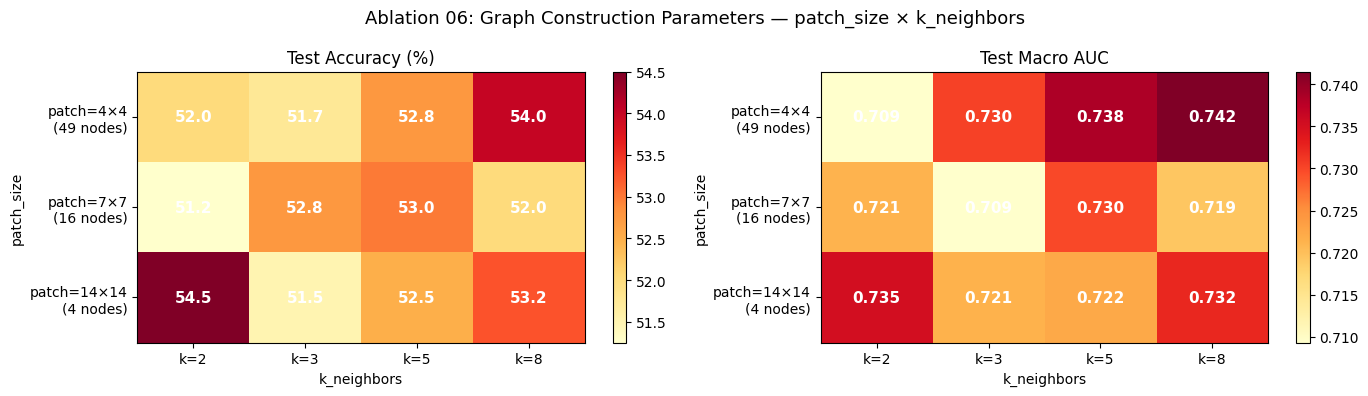


Best config: patch_size=14  k=2  acc=54.50%  auc=0.7352


In [ ]:
accs = np.array([[grid_results[(ps,k)]["acc"]*100 for k in K_NEIGHBORS] for ps in PATCH_SIZES])
aucs = np.array([[grid_results[(ps,k)]["auc"]     for k in K_NEIGHBORS] for ps in PATCH_SIZES])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, title, fmt in [
    (axes[0], accs, "Test Accuracy (%)",  "{:.1f}"),
    (axes[1], aucs, "Test Macro AUC",     "{:.3f}"),
]:
    im = ax.imshow(data, cmap="YlOrRd", aspect="auto")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(K_NEIGHBORS))); ax.set_xticklabels([f"k={k}" for k in K_NEIGHBORS])
    ax.set_yticks(range(len(PATCH_SIZES)));  ax.set_yticklabels([f"patch={p}×{p}\n({(28//p)**2} nodes)" for p in PATCH_SIZES])
    ax.set_title(title); ax.set_xlabel("k_neighbors"); ax.set_ylabel("patch_size")
    for i in range(len(PATCH_SIZES)):
        for j in range(len(K_NEIGHBORS)):
            ax.text(j, i, fmt.format(data[i,j]), ha="center", va="center",
                    color="black" if data[i,j] < data.max()*0.85 else "white", fontsize=11, fontweight="bold")

plt.suptitle("Ablation 06: Graph Construction Parameters — patch_size × k_neighbors", fontsize=13)
plt.tight_layout()
plt.savefig(f"{ABLATION_DIR}/ablation06_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

best_config = max(grid_results.keys(), key=lambda k: grid_results[k]["acc"])
print(f"\nBest config: patch_size={best_config[0]}  k={best_config[1]}  acc={grid_results[best_config]['acc']*100:.2f}%  auc={grid_results[best_config]['auc']:.4f}")
